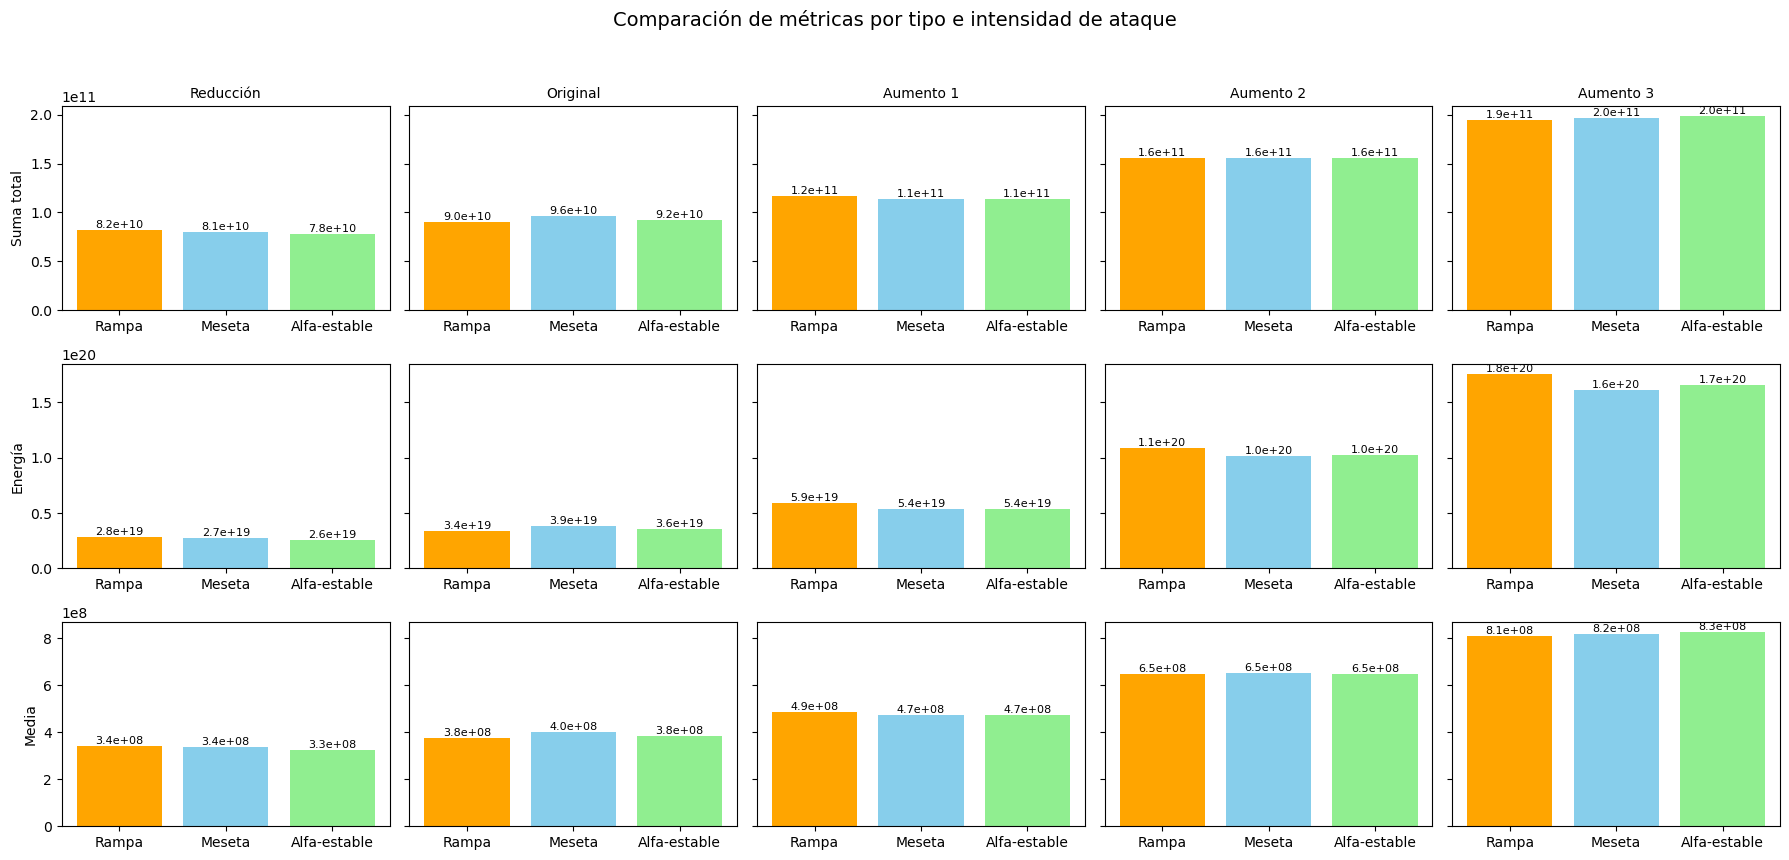

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Función para calcular métricas ===
def calcular_metricas(serie):
    bloque1 = serie[2580:2700] #Para ver el numero de bits en los tramos de ataque
    #bloque1 = serie #Para ver el numero de bits en toda la serie
    #bloque1 = serie[0:2579] #Para ver las metricas en la parte sin ataque
    
    bloque2 = serie[5280:5400] #Para ver el numero de bits en los tramos de ataque
    #bloque2 = serie #Para ver el numero de bits en toda la serie
    #bloque2 = serie[2701:5279] #Para ver las metricas en la parte sin ataque

    #bloque3 = serie[5401:7200] #Para ver las metricas en la parte sin ataque

    suma = float(np.sum(bloque1) + np.sum(bloque2))
    energia = float(np.sum(bloque1**2) + np.sum(bloque2**2))
    media = float((np.mean(bloque1) + np.mean(bloque2)) / 2)

    #Para ver las metricas en la parte sin ataque
    #suma = float(np.sum(bloque1) + np.sum(bloque2) + np.sum(bloque3))
    #energia = float(np.sum(bloque1**2) + np.sum(bloque2**2) + np.sum(bloque3**2))
    #media = float((np.mean(bloque1) + np.mean(bloque2) + np.mean(bloque3)) / 3)
    
    return suma, energia, media

# === Diccionario con rutas por caso ===
casos = {
    'Reducción': [
        'series_concatenadas_rampa/cambio_intensidades/archivo_concatenado_miercoles_intensidad_1-0_4_2intento.csv',
        'series_concatenadas_meseta/cambio_intensidades/archivo_concatenado_miercoles_intensidad_0_1_2intento.csv',
        'series_concatenadas/archivo_concatenado_miercoles_cambio_0_55.csv'
    ],
    'Original': [
        'series_concatenadas_rampa/archivo_concatenado_miercoles.csv',
        'series_concatenadas_meseta/archivo_concatenado_miercoles.csv',
        'series_concatenadas/archivo_concatenado_miercoles.csv'
    ],
    'Aumento 1': [
        'series_concatenadas_rampa/cambio_intensidades/archivo_concatenado_miercoles_intensidad_1+0_5_2intento.csv',
        'series_concatenadas_meseta/cambio_intensidades/archivo_concatenado_miercoles_intensidad_1_5_2intento.csv',
        'series_concatenadas/archivo_concatenado_miercoles_cambio_0_8.csv'
    ],
    'Aumento 2': [
        'series_concatenadas_rampa/cambio_intensidades/archivo_concatenado_miercoles_intensidad_1+1_5_2intento.csv',
        'series_concatenadas_meseta/cambio_intensidades/archivo_concatenado_miercoles_intensidad_3_3_2intento.csv',
        'series_concatenadas/archivo_concatenado_miercoles_cambio_1_1.csv'
    ],
    'Aumento 3': [
        'series_concatenadas_rampa/cambio_intensidades/archivo_concatenado_miercoles_intensidad_1+2_5_2intento.csv',
        'series_concatenadas_meseta/cambio_intensidades/archivo_concatenado_miercoles_intensidad_5_2intento.csv',
        'series_concatenadas/archivo_concatenado_miercoles_cambio_1_4.csv'
    ]
}

# === Preparar subplots (3 filas: suma, energía, media) ===
fig, axs = plt.subplots(3, 5, figsize=(18, 9), sharey='row')
tipos = ['Rampa', 'Meseta', 'Alfa-estable']

for col, (nombre_caso, rutas) in enumerate(casos.items()):
    sumas, energias, medias = [], [], []

    for ruta in rutas:
        serie = pd.read_csv(ruta).iloc[:, 0]
        suma, energia, media = calcular_metricas(serie)
        sumas.append(suma)
        energias.append(energia)
        medias.append(media)

    # Gráfico de sumas
    bars = axs[0, col].bar(tipos, sumas, color=['orange', 'skyblue', 'lightgreen'])
    axs[0, col].set_title(nombre_caso, fontsize=10)
    for bar, val in zip(bars, sumas):
        axs[0, col].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.1e}', ha='center', va='bottom', fontsize=8)

    # Gráfico de energías
    bars = axs[1, col].bar(tipos, energias, color=['orange', 'skyblue', 'lightgreen'])
    for bar, val in zip(bars, energias):
        axs[1, col].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.1e}', ha='center', va='bottom', fontsize=8)

    # Gráfico de medias (también en notación científica)
    bars = axs[2, col].bar(tipos, medias, color=['orange', 'skyblue', 'lightgreen'])
    for bar, val in zip(bars, medias):
        axs[2, col].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.1e}', ha='center', va='bottom', fontsize=8)

# Etiquetas de fila
axs[0, 0].set_ylabel('Suma total')
axs[1, 0].set_ylabel('Energía')
axs[2, 0].set_ylabel('Media')

# Título general
fig.suptitle('Comparación de métricas por tipo e intensidad de ataque', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


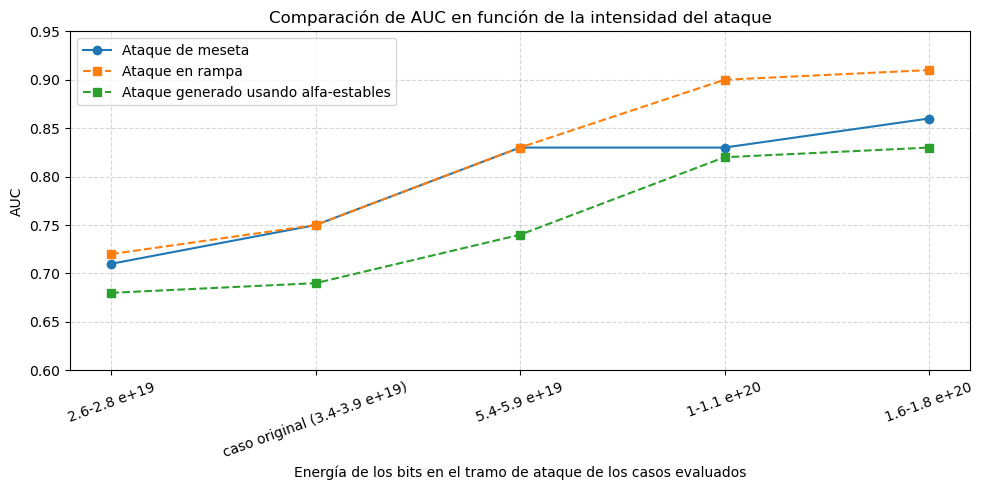

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Etiquetas comunes para ambos casos (alineadas por orden)
etiquetas_energia = [
    '2.6-2.8 e+19', 'caso original (3.4-3.9 e+19)', '5.4-5.9 e+19', '1-1.1 e+20', '1.6-1.8 e+20'
]

etiquetas_suma = [
    '7.8-8.2 e+10', 'caso original (9-9.6 e+10)', '1.1-1.2 e+11', '1.6 e+11', '1.9-2 e+11'
]

etiquetas_media = [
    '3.3-3.4 e+08', 'caso original (3.8-4 e+08)', '4.7-4.9 e+08', '6.5 e+08', '8.1-8.3 e+08'
]

auc_0_1 = 0.71
auc_orig = 0.74
auc_1_5 = 0.8
auc_3 = 0.83
auc_3_3 = 0.83 #Accuracy:69.52
auc_4 = 0.85
auc_5 = 0.86 #Accuracy:75.4


auc_menos_0_4 = 0.72
auc_orig = 0.75
auc_mas_0_5 = 0.83
auc_mas_1_5 = 0.9
auc_mas_2_5 = 0.91



auc_0_5 = 0.65 #Accuracy:60.57 
auc_0_55 = 0.68 #Accuracy: 60.91
auc_0_57 = 0.67 #Accuracy: 61.12
auc_0_65 = 0.69 #Accuracy:61 
auc_0_8 = 0.74 #Accuracy:62.99 
auc_0_9 = 0.77 #Accuracy:66.48
auc_1 = 0.80 #Accuracy:69.44   
auc_1_1 = 0.82 #Accuracy:69.44     
auc_1_2 = 0.82 #Accuracy:70.16 
auc_1_4 = 0.83 #Accuracy:70.85
auc_1_5 = 0.83#Accuracy:71.24

# AUC para el ataque tipo 1 (relleno con None para igualar longitud)
#auc_ataque_meseta = [0.71, 0.74, 0.8, 0.83, 0.85]
auc_ataque_meseta = [auc_0_1, auc_orig, auc_1_5, auc_3_3, auc_5]

# AUC para el ataque tipo 2 (relleno con None al principio)
auc_ataque_rampa = [auc_menos_0_4, auc_orig, auc_mas_0_5, auc_mas_1_5, auc_mas_2_5]

#auc_ataque_alfa = [auc_0_5, auc_0_65, auc_0_8, auc_1, auc_1_2]
auc_ataque_alfa = [auc_0_55, auc_0_65, auc_0_8, auc_1_1, auc_1_4]

x = np.arange(len(etiquetas_energia))  # [0, 1, 2, 3, 4]

plt.figure(figsize=(10, 5))

# Plot de cada curva
plt.plot(x, auc_ataque_meseta, marker='o', label='Ataque de meseta', linestyle='-')
plt.plot(x, auc_ataque_rampa, marker='s', label='Ataque en rampa', linestyle='--')
plt.plot(x, auc_ataque_alfa, marker='s', label='Ataque generado usando alfa-estables', linestyle='--')

# Personalización del eje X
#ENERGÍA
plt.xticks(x, etiquetas_energia, rotation=20)
plt.xlabel('Energía de los bits en el tramo de ataque de los casos evaluados')
#SUMA
#plt.xticks(x, etiquetas_suma, rotation=20)
#plt.xlabel('Suma de bits en el tramo de ataque de los casos evaluados')
#MEDIA
#plt.xticks(x, etiquetas_media, rotation=20)
#plt.xlabel('Media de los bits en el tramo de ataque de los casos evaluados')

plt.ylabel('AUC')
plt.title('Comparación de AUC en función de la intensidad del ataque')
plt.ylim(0.6, 0.95)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

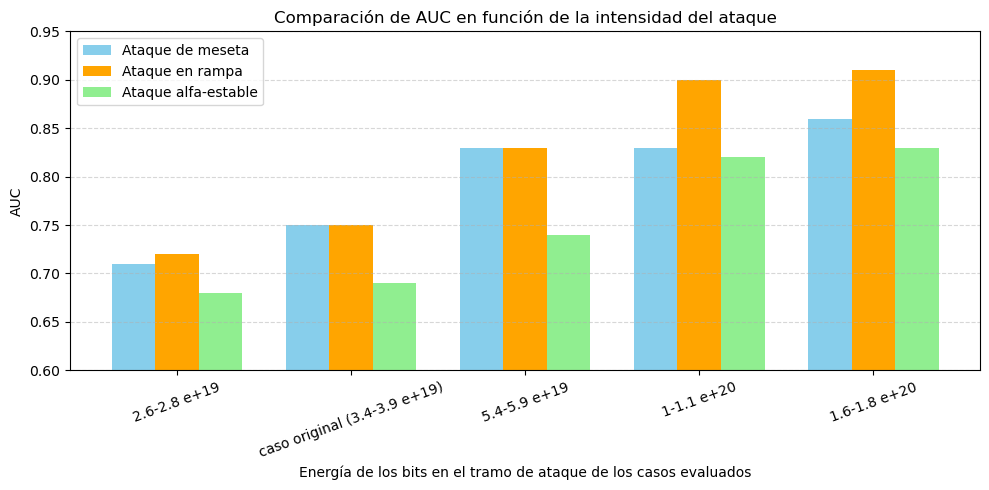

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Etiquetas comunes para ambos casos (alineadas por orden)
etiquetas_energia = [
    '2.6-2.8 e+19', 'caso original (3.4-3.9 e+19)', '5.4-5.9 e+19', '1-1.1 e+20', '1.6-1.8 e+20'
]

etiquetas_suma = [
    '7.8-8.2 e+10', 'caso original (9-9.6 e+10)', '1.1-1.2 e+11', '1.6 e+11', '1.9-2 e+11'
]

etiquetas_media = [
    '3.3-3.4 e+08', 'caso original (3.8-4 e+08)', '4.7-4.9 e+08', '6.5 e+08', '8.1-8.3 e+08'
]

# AUC para el ataque tipo 1 (relleno con None para igualar longitud)
#auc_ataque_meseta = [0.71, 0.74, 0.8, 0.83, 0.85]
auc_ataque_meseta = [auc_0_1, auc_orig, auc_1_5, auc_3_3, auc_5]

# AUC para el ataque tipo 2 (relleno con None al principio)
auc_ataque_rampa = [auc_menos_0_4, auc_orig, auc_mas_0_5, auc_mas_1_5, auc_mas_2_5]

#auc_ataque_alfa = [auc_0_5, auc_0_65, auc_0_8, auc_1, auc_1_2]
auc_ataque_alfa = [auc_0_55, auc_0_65, auc_0_8, auc_1_1, auc_1_4]

x = np.arange(len(etiquetas_energia))  # posiciones base para los grupos
width = 0.25  # ancho de cada barra

# Crear gráfico
plt.figure(figsize=(10, 5))

plt.bar(x - width, auc_ataque_meseta, width, label='Ataque de meseta', color='skyblue')
plt.bar(x, auc_ataque_rampa, width, label='Ataque en rampa', color='orange')
plt.bar(x + width, auc_ataque_alfa, width, label='Ataque alfa-estable', color='lightgreen')

# Eje x y etiquetas
#ENERGÍA
plt.xticks(x, etiquetas_energia, rotation=20)
plt.xlabel('Energía de los bits en el tramo de ataque de los casos evaluados')
#SUMA
#plt.xticks(x, etiquetas_suma, rotation=20)
#plt.xlabel('Suma de bits en el tramo de ataque de los casos evaluados')
#MEDIA
#plt.xticks(x, etiquetas_media, rotation=20)
#plt.xlabel('Media de los bits en el tramo de ataque de los casos evaluados')

plt.ylabel('AUC')
plt.title('Comparación de AUC en función de la intensidad del ataque')

# Límites y formato
plt.ylim(0.6, 0.95)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
#plt.savefig("figuras_memoria/variacion_intensidades.pdf")
plt.show()


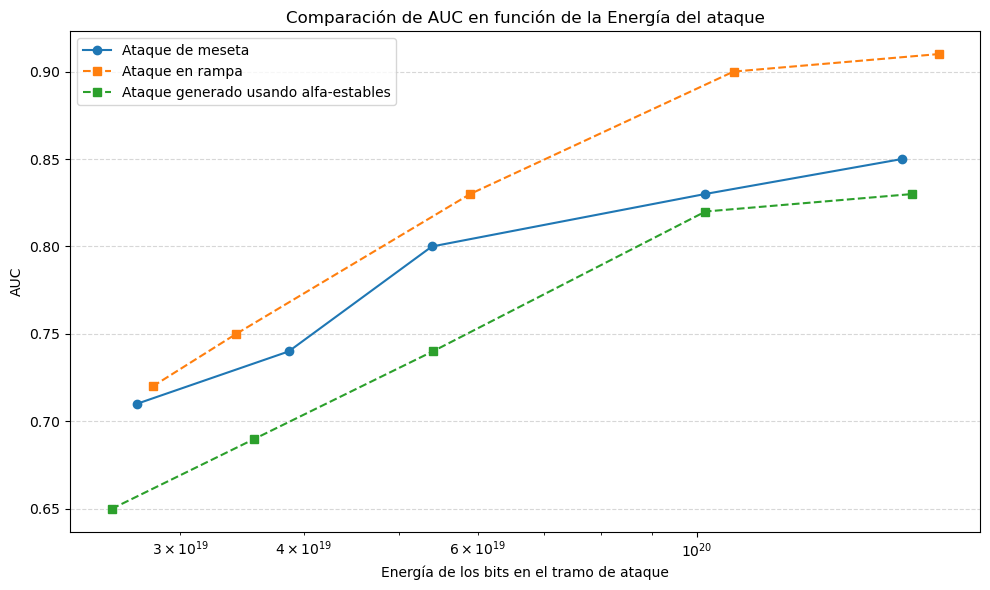

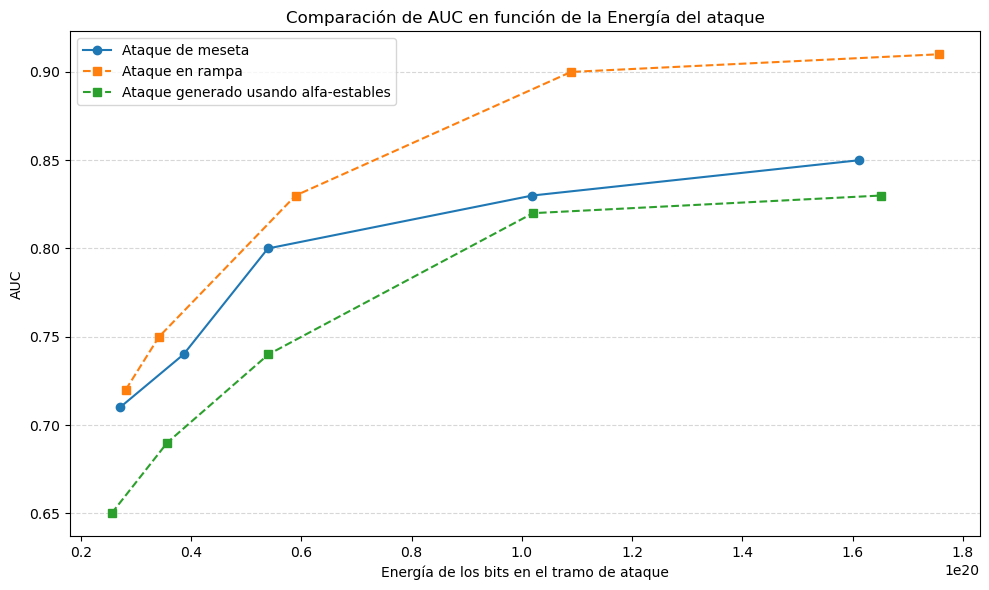

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Valores Energía
energia_meseta = [2.710e+19, 3.862e+19, 5.392e+19, 1.019e+20, 1.612e+20]
energia_rampa = [2.813e+19, 3.417e+19, 5.895e+19, 1.089e+20, 1.756e+20]
energia_alfa = [2.557e+19, 3.566e+19, 5.402e+19, 1.020e+20, 1.652e+20]

auc_ataque_meseta = [0.71, 0.74, 0.8, 0.83, 0.85]
auc_ataque_rampa = [0.72, 0.75, 0.83, 0.9, 0.91]
auc_ataque_alfa = [0.65, 0.69, 0.74, 0.82, 0.83]

plt.figure(figsize=(10, 6))

# Ajustar ancho de las barras proporcional al valor
def calcular_width(valores):
    return np.array(valores) * 0.05  # 5% del valor para hacerlo visible

#plt.bar(energia_meseta, auc_ataque_meseta, width=calcular_width(energia_meseta), label='Meseta', color='skyblue')
#plt.bar(energia_rampa, auc_ataque_rampa, width=calcular_width(energia_rampa), label='Rampa', color='orange')
#plt.bar(energia_alfa, auc_ataque_alfa, width=calcular_width(energia_alfa), label='Alfa-estable', color='lightgreen')

plt.plot(energia_meseta, auc_ataque_meseta, marker='o', label='Ataque de meseta', linestyle='-')
plt.plot(energia_rampa, auc_ataque_rampa, marker='s', label='Ataque en rampa', linestyle='--')
plt.plot(energia_alfa, auc_ataque_alfa, marker='s', label='Ataque generado usando alfa-estables', linestyle='--')

plt.xscale('log')
plt.xlabel('Energía de los bits en el tramo de ataque')
plt.ylabel('AUC')
plt.title('Comparación de AUC en función de la Energía del ataque')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
#plt.savefig('figuras_memoria/comparacion_auc_logaritmica.pdf')
plt.show()

plt.figure(figsize=(10, 6))

# Ajustar ancho de las barras proporcional al valor
def calcular_width(valores):
    return np.array(valores) * 0.05  # 5% del valor para hacerlo visible

#plt.bar(energia_meseta, auc_ataque_meseta, width=calcular_width(energia_meseta), label='Meseta', color='skyblue')
#plt.bar(energia_rampa, auc_ataque_rampa, width=calcular_width(energia_rampa), label='Rampa', color='orange')
#plt.bar(energia_alfa, auc_ataque_alfa, width=calcular_width(energia_alfa), label='Alfa-estable', color='lightgreen')

plt.plot(energia_meseta, auc_ataque_meseta, marker='o', label='Ataque de meseta', linestyle='-')
plt.plot(energia_rampa, auc_ataque_rampa, marker='s', label='Ataque en rampa', linestyle='--')
plt.plot(energia_alfa, auc_ataque_alfa, marker='s', label='Ataque generado usando alfa-estables', linestyle='--')

#plt.xscale('log')
plt.xlabel('Energía de los bits en el tramo de ataque')
plt.ylabel('AUC')
plt.title('Comparación de AUC en función de la Energía del ataque')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
#plt.savefig('figuras_memoria/comparacion_auc_lineal.pdf')
plt.show()


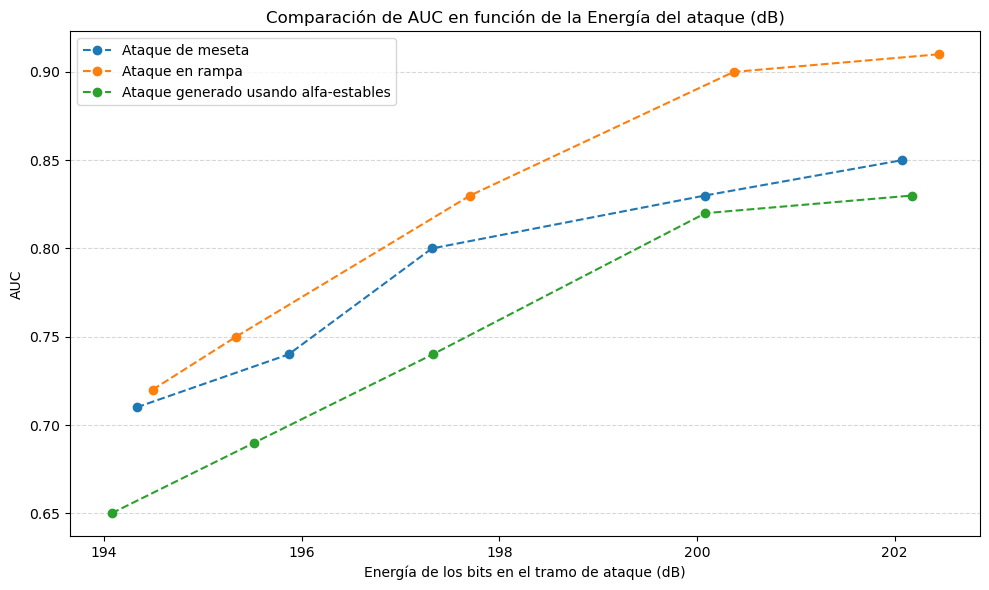

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Valores Energía
energia_meseta = [2.710e+19, 3.862e+19, 5.392e+19, 1.019e+20, 1.612e+20]
energia_rampa = [2.813e+19, 3.417e+19, 5.895e+19, 1.089e+20, 1.756e+20]
energia_alfa = [2.557e+19, 3.566e+19, 5.402e+19, 1.020e+20, 1.652e+20]

auc_ataque_meseta = [0.71, 0.74, 0.8, 0.83, 0.85]
auc_ataque_rampa = [0.72, 0.75, 0.83, 0.9, 0.91]
auc_ataque_alfa = [0.65, 0.69, 0.74, 0.82, 0.83]

# Convertir a decibelios
energia_meseta_db = 10 * np.log10(energia_meseta)
energia_rampa_db = 10 * np.log10(energia_rampa)
energia_alfa_db = 10 * np.log10(energia_alfa)

plt.figure(figsize=(10, 6))

plt.plot(energia_meseta_db, auc_ataque_meseta, marker='o', label='Ataque de meseta', linestyle='--')
plt.plot(energia_rampa_db, auc_ataque_rampa, marker='o', label='Ataque en rampa', linestyle='--')
plt.plot(energia_alfa_db, auc_ataque_alfa, marker='o', label='Ataque generado usando alfa-estables', linestyle='--')

plt.xlabel('Energía de los bits en el tramo de ataque (dB)')
plt.ylabel('AUC')
plt.title('Comparación de AUC en función de la Energía del ataque (dB)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
#plt.savefig('figuras_memoria/comparacion_auc_db.pdf')
plt.show()
